In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
np.random.seed(42)
tf.random.set_seed(42)

## Load the data

In [3]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
y_train = y_train.flatten()
y_test = y_test.flatten()

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}\n")

print(f"X_train dimensions: {X_train.ndim}")
print(f"y_train dimensions: {y_train.ndim}\n")

print(f"X_train data type: {X_train.dtype}")
print(f"y_train data type: {y_train.dtype}")

X_train shape: (50000, 32, 32, 3)
y_train shape: (50000,)
X_test shape: (10000, 32, 32, 3)
y_test shape: (10000,)

X_train dimensions: 4
y_train dimensions: 1

X_train data type: uint8
y_train data type: uint8


## Data visualization

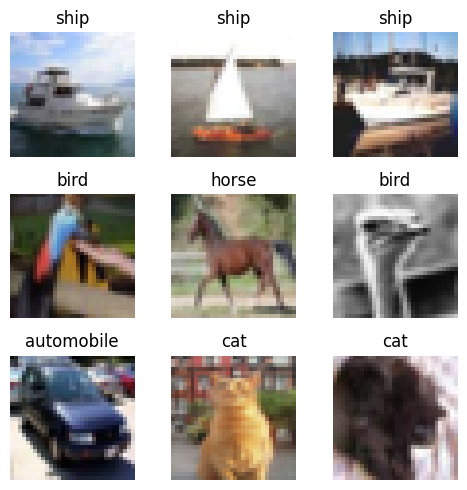

In [4]:
# Define the labels of the dataset
labels = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
          'dog', 'frog', 'horse', 'ship', 'truck']

# Grid size
W_grid, L_grid = 3, 3

# Create subplots
fig, axes = plt.subplots(L_grid, W_grid, figsize=(5,5))
axes = axes.ravel()

n_train = len(X_train)

for i in range(W_grid * L_grid):
    # Random index
    index = np.random.randint(0, n_train)
    
    # Get the image
    image = X_train[index]
    
    axes[i].imshow(image)
    
    label_index = y_train[index]
    
    axes[i].set_title(labels[label_index], fontsize=12)
    axes[i].axis('off')

plt.tight_layout()
plt.show()


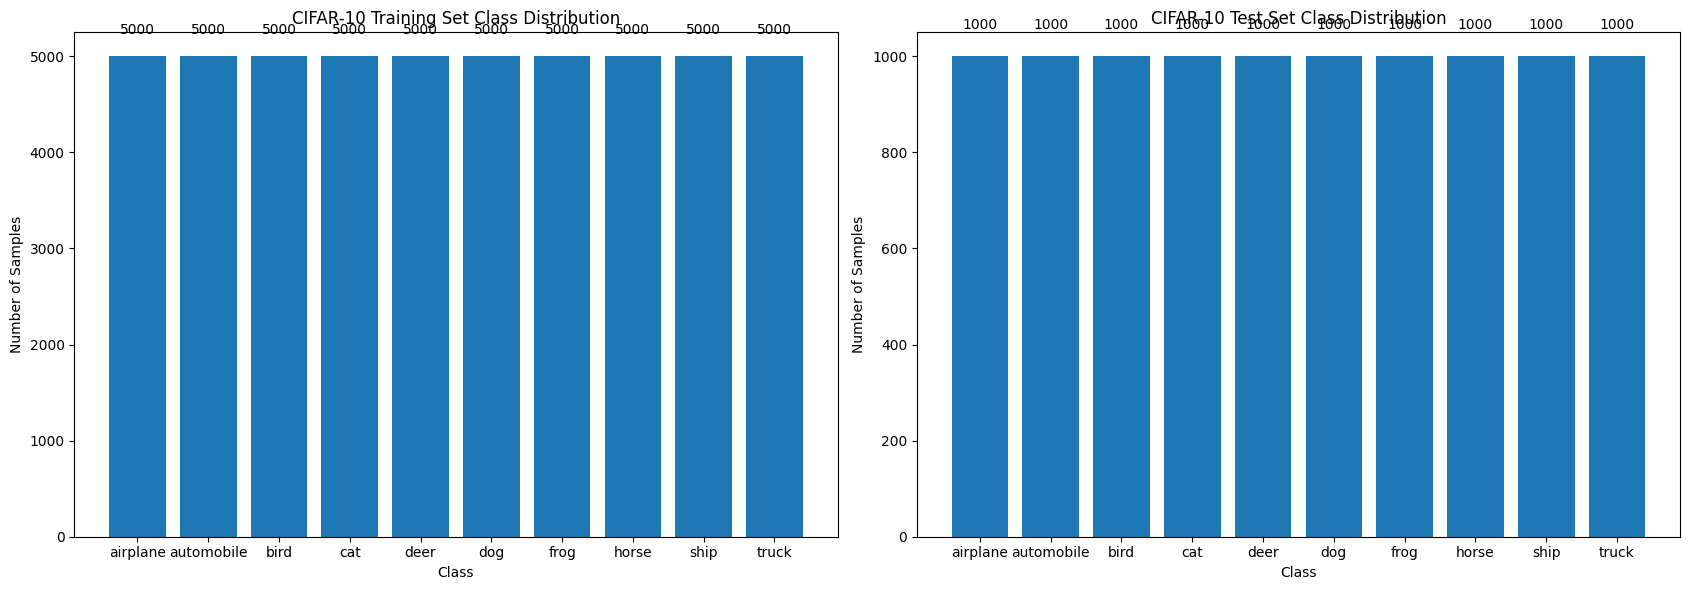

In [5]:
# CIFAR-10 class names
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']


# Count class occurrences
train_counts = np.bincount(y_train, minlength=10)
test_counts  = np.bincount(y_test, minlength=10)

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# Training set
bars_train = axes[0].bar(classes, train_counts)
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Number of Samples')
axes[0].set_title('CIFAR-10 Training Set Class Distribution')
for bar, count in zip(bars_train, train_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 str(count), ha='center', va='bottom', fontsize=10)

# Test set
bars_test = axes[1].bar(classes, test_counts)
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Number of Samples')
axes[1].set_title('CIFAR-10 Test Set Class Distribution')
for bar, count in zip(bars_test, test_counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 str(count), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


## Data preprocessing

In [6]:
# Transform target variable into one-hot encoding
y_cat_train = to_categorical(y_train, 10)
y_cat_test = to_categorical(y_test, 10)

## Model building

In [7]:
INPUT_SHAPE = (32, 32, 3)
KERNEL_SIZE = (3, 3)

model = Sequential()

# Block 1
model.add(Conv2D(32, KERNEL_SIZE, activation='relu', padding='same',
                 input_shape=INPUT_SHAPE))
model.add(BatchNormalization())
model.add(Conv2D(32, KERNEL_SIZE, activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPool2D((2, 2)))
model.add(Dropout(0.25))

# Block 2
model.add(Conv2D(64, KERNEL_SIZE, activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(64, KERNEL_SIZE, activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPool2D((2, 2)))
model.add(Dropout(0.25))

# Fully connected
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.25))
model.add(Dense(10, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/Users/panagiotistsagkaroulis/Documents/Projects/Repositories/cifar10-image-classification/.venv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-01-21 11:32:02.994274: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-01-21 11:32:02.994324: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-01-21 11:32:02.994333: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
2026-01-21 11:32:02.994501: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-01-21 11:32:02.994521: I 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 592,042 (2.26 MB)

 Trainable params: 591,658 (2.26 MB)

 Non-trainable params: 384 (1.50 KB)

## Early Stopping

In [8]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

## Data Augmentations

In [9]:
batch_size = 32

# Training data generator with augmentation AND scaling
train_datagen = ImageDataGenerator(
    rescale=1./255,  # Scale to [0, 1]
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2  # Use 20% for validation
)

# Test data generator with ONLY scaling (no augmentation)
test_datagen = ImageDataGenerator(
    rescale=1./255
)

# Create generators
train_generator = train_datagen.flow(
    X_train, y_cat_train,
    batch_size=batch_size,
    subset='training'
)

val_generator = train_datagen.flow(
    X_train, y_cat_train,
    batch_size=batch_size,
    subset='validation'
)

test_generator = test_datagen.flow(
    X_test, y_cat_test,
    batch_size=batch_size,
    shuffle=False
)

## Train the model
r = model.fit(
    train_generator,
    epochs=50,
    validation_data=val_generator,  # Fixed: use properly preprocessed validation data
    callbacks=[early_stop]
)


Epoch 1/50


2026-01-21 11:32:06.564316: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 36s 26ms/step - accuracy: 0.2830 - loss: 5.8509 - val_accuracy: 0.3662 - val_loss: 2.5259
Epoch 2/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 33s 26ms/step - accuracy: 0.4344 - loss: 1.8020 - val_accuracy: 0.5473 - val_loss: 1.2743
Epoch 3/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 33s 26ms/step - accuracy: 0.5114 - loss: 1.4671 - val_accuracy: 0.5832 - val_loss: 1.2302
Epoch 4/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 34s 27ms/step - accuracy: 0.5368 - loss: 1.4842 - val_accuracy: 0.5090 - val_loss: 1.6305
Epoch 5/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 33s 27ms/step - accuracy: 0.5468 - loss: 1.6048 - val_accuracy: 0.5784 - val_loss: 1.5978
Epoch 6/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 34s 27ms/step - accuracy: 0.5567 - loss: 1.7485 - val_accuracy: 0.5239 - val_loss: 2.2453
Epoch 7/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 33s 26ms/step - accuracy: 0.5641 - loss: 1.9143 - val_accuracy: 0.6441 - val_loss: 1.3506
Epoch 8/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 33s 26ms/step - accuracy: 0.5692 - loss: 2.16

## Model Evaluation

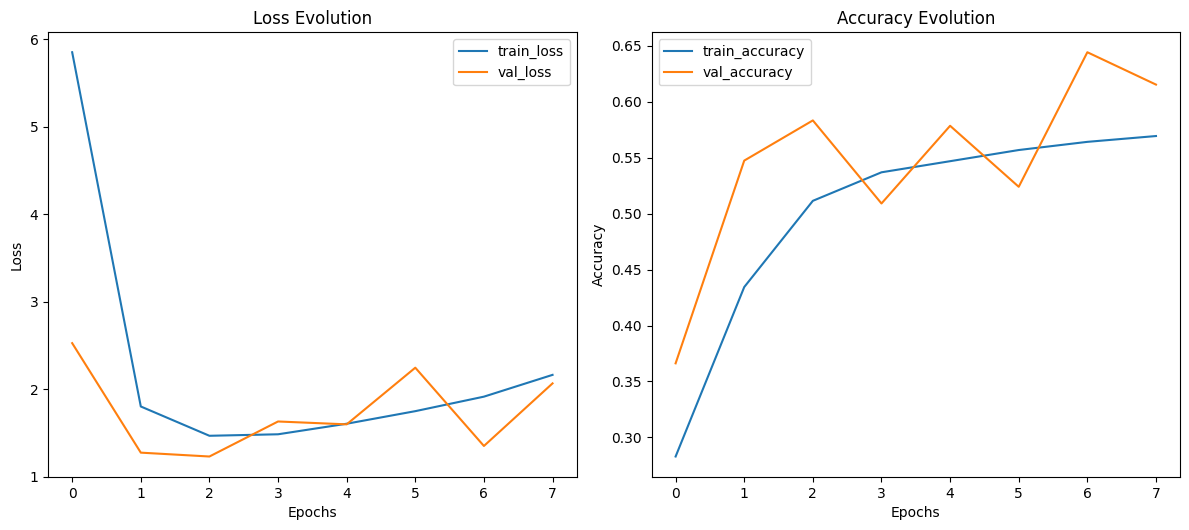

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6102 - loss: 1.1677
Test Accuracy: 61.02%
Test Loss: 1.1677


In [10]:
plt.figure(figsize=(12, 10))

# Loss plot
plt.subplot(2, 2, 1)
plt.plot(r.history['loss'], label='train_loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.title('Loss Evolution')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy plot
plt.subplot(2, 2, 2)
plt.plot(r.history['accuracy'], label='train_accuracy')
plt.plot(r.history['val_accuracy'], label='val_accuracy')
plt.title('Accuracy Evolution')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Evaluate on test set
evaluation = model.evaluate(test_generator)
print(f'Test Accuracy: {evaluation[1] * 100:.2f}%')
print(f'Test Loss: {evaluation[0]:.4f}')

## Generate predictions

In [11]:
test_generator.reset()  # Reset generator to start from beginning
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


## Classification report

In [12]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=labels))


Classification Report:
              precision    recall  f1-score   support

    airplane       0.61      0.71      0.66      1000
  automobile       0.69      0.87      0.77      1000
        bird       0.60      0.32      0.41      1000
         cat       0.38      0.57      0.46      1000
        deer       0.50      0.60      0.55      1000
         dog       0.75      0.28      0.40      1000
        frog       0.71      0.74      0.72      1000
       horse       0.65      0.67      0.66      1000
        ship       0.87      0.55      0.68      1000
       truck       0.62      0.79      0.69      1000

    accuracy                           0.61     10000
   macro avg       0.64      0.61      0.60     10000
weighted avg       0.64      0.61      0.60     10000



## Confusion Matrix

<Figure size 800x800 with 0 Axes>

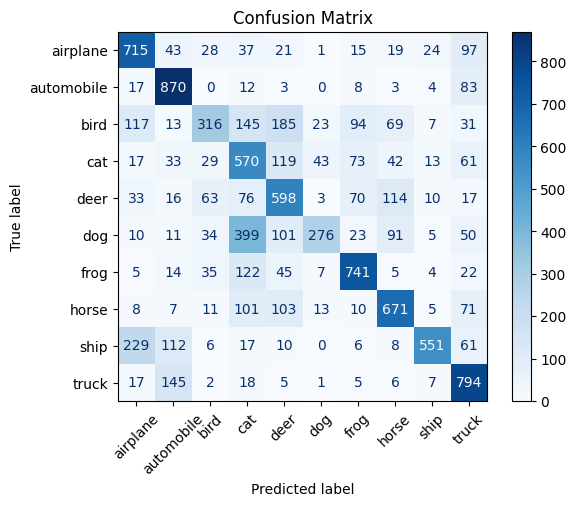

In [13]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=labels)

plt.figure(figsize=(8, 8))
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title('Confusion Matrix')
plt.show()

## Single image prediction

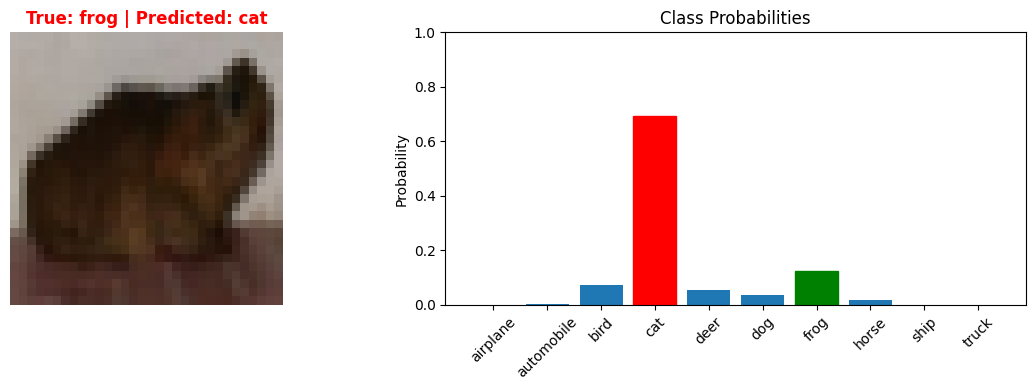

In [14]:
# Scale test data for individual predictions
X_test_scaled = X_test / 255.0

idx = np.random.randint(0, len(X_test))

image = X_test[idx]  # Display original
image_scaled = X_test_scaled[idx]  # Use scaled for prediction
true_label = y_test[idx]

probs = model.predict(image_scaled[np.newaxis, ...], verbose=0)[0]
pred_label = np.argmax(probs)

plt.figure(figsize=(12, 4))

# Image
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.axis('off')
color = 'green' if pred_label == true_label else 'red'
plt.title(f"True: {labels[true_label]} | Predicted: {labels[pred_label]}", 
          color=color, fontweight='bold')

# Probability bar chart
plt.subplot(1, 2, 2)
bars = plt.bar(labels, probs)
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.ylabel("Probability")
plt.title("Class Probabilities")

# Highlight bars
bars[pred_label].set_color('red')
bars[true_label].set_color('green')

plt.tight_layout()
plt.show()

## Grid of predictions


Sample accuracy on 100 random images: 60/100 = 60.00%


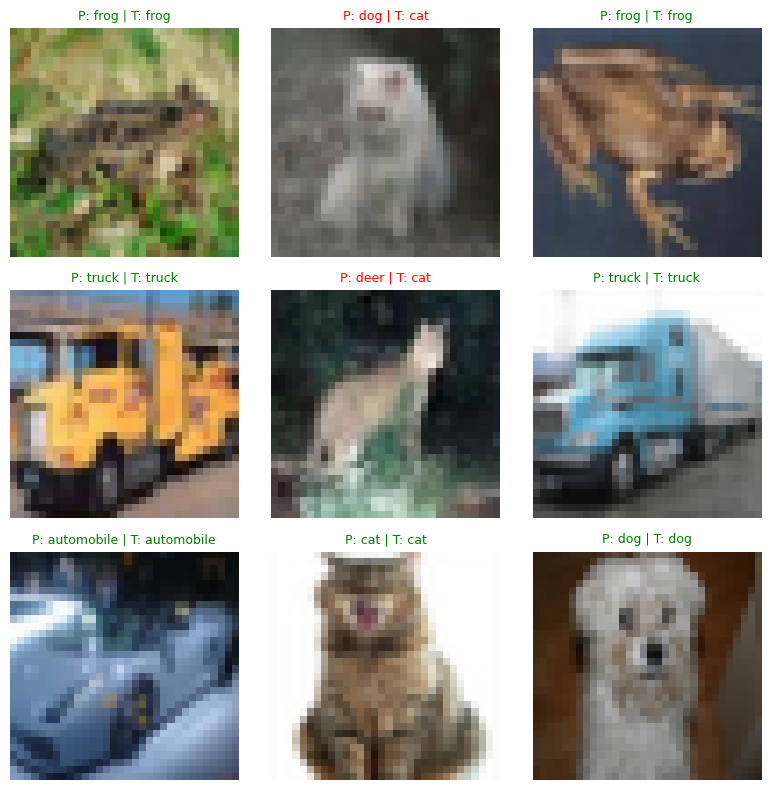

In [15]:
# 100 random samples for accuracy
n = 100
indices = np.random.choice(len(X_test), n, replace=False)

images_batch = X_test_scaled[indices]
predictions = model.predict(images_batch, verbose=0)
pred_labels = np.argmax(predictions, axis=1)

correct = np.sum(pred_labels == y_test[indices])
print(f"\nSample accuracy on 100 random images: {correct}/{n} = {correct/n:.2%}")

# --- Optional: show a smaller grid of 9 random images ---
grid_n = 9
grid_indices = np.random.choice(indices, grid_n, replace=False)

images_grid = X_test_scaled[grid_indices]
pred_grid = pred_labels[np.isin(indices, grid_indices)]
true_grid = y_test[grid_indices]

plt.figure(figsize=(8, 8))
for i, idx in enumerate(grid_indices):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_test[idx])
    pred = pred_labels[np.where(indices == idx)][0]
    true = y_test[idx]
    color = 'green' if pred == true else 'red'
    plt.title(f"P: {labels[pred]} | T: {labels[true]}", fontsize=9, color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()


# Calculate accuracy on this sample

In [16]:
correct = np.sum(pred_labels == y_test[indices])
print(f"\nSample grid accuracy: {correct}/{n} = {correct/n:.2%}")


Sample grid accuracy: 60/100 = 60.00%
